## Import Libraries

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [16]:
dataset = "https://raw.githubusercontent.com/RaiyanEOF/CSE-330-Lab/refs/heads/main/lab1_data.csv"
df = pd.read_csv(dataset)
df

,Duration,Pulse,Maxpulse,Calories
0,60,110,130,409.1
1,60,117,145,479.0
2,60,103,135,340.0
3,45,109,175,282.4
4,45,117,148,406.0
...,...,...,...,...
164,60,105,140,290.8
165,60,110,145,300.0
166,60,115,145,310.2
167,75,120,150,320.4


## Explore DataSet

In [17]:
df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  169 non-null    int64  
 1   Pulse     169 non-null    int64  
 2   Maxpulse  169 non-null    int64  
 3   Calories  164 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 5.4 KB


(169, 4)

## Check Missing values

In [27]:
df.isnull().sum()


,0
Duration,0
Pulse,0
Maxpulse,0
Calories,5


## Select Feature and Target

In [30]:
df = df.dropna(subset=["Calories"])
X = df.drop('Calories', axis=1)
y = df['Calories']

## Train Test Split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

## Create Pipeline

In [32]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

## Train Model

In [33]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', LinearRegression())])

## Prediction

In [36]:
y_pred = pipeline.predict(X_test)
print(y_pred)

[228.46679624 323.29180393 208.5340372  295.0687013  173.08901619
 191.5454938  234.63472645 400.45743627 100.30039949 347.60157861
 345.15426911 729.43170771 307.21845715 119.81278105 310.56026605
 319.94999503 296.48080407 467.58737892 310.56026605 310.56026605
 280.92506066 228.32800468 336.02334181 314.93728168 285.35599197
 111.76054194 448.29031759 267.81471097 280.1486556  375.51196387
 467.19813289 355.04925145 933.66452265]


## Model Evaluation

In [39]:
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 42.05679273325248
MSE : 4354.413282161518
RMSE: 65.98797831545923
R² Score: 0.8664689420685994


## Actual vs Prediction

In [40]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
139,222.4,228.466796
119,332.7,323.291804
135,189.0,208.534037
57,305.0,295.068701
98,188.2,173.089016
31,180.1,191.545494
162,270.0,234.634726
53,486.0,400.457436
104,92.7,100.300399
150,343.0,347.601579


## Scatter Plot

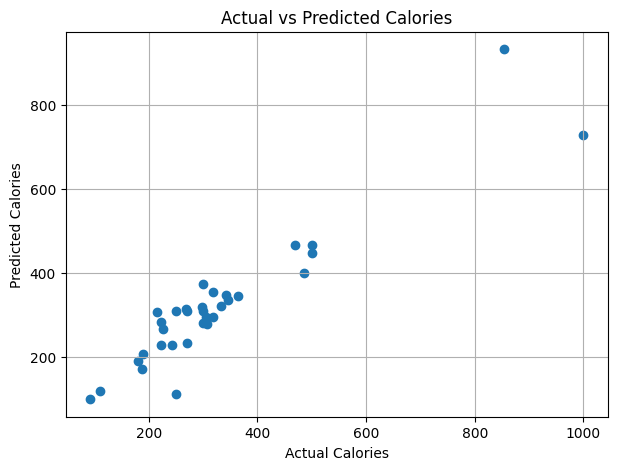

In [44]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Calories")

plt.ylabel("Predicted Calories")

plt.title("Actual vs Predicted Calories")
plt.grid()

plt.show()

## Residual Plot

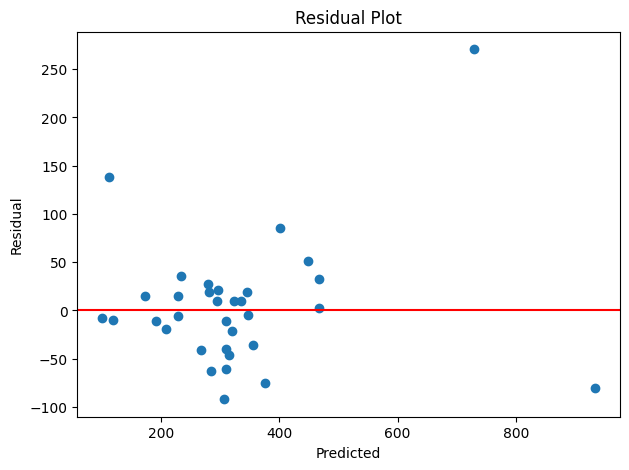

In [47]:
residual = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residual)

plt.axhline(0, color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

## Feature Importance

In [48]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": pipeline.named_steps["model"].coef_
})

coef

,Feature,Coefficient
0,Duration,263.024142
1,Pulse,22.868537
2,Maxpulse,30.871447


## Model Selection

In [49]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [50]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()),
                ('model', RandomForestRegressor(random_state=42))])

In [51]:
rf_pred = rf_pipeline.predict(X_test)

In [52]:
print("R² :", r2_score(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

R² : 0.7391735544730896
RMSE : 92.22517534032231


## Cross validation

In [53]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average R²:", scores.mean())

[ 0.44432221  0.94072422  0.87349808  0.86442169 -0.20861964]
Average R²: 0.5828693129522515


## Save Model, Load later & Prediction

In [54]:
import joblib

joblib.dump(pipeline, "calorie_prediction_model.pkl")

['calorie_prediction_model.pkl']

In [56]:
model = joblib.load("calorie_prediction_model.pkl")
print("Model Loaded Successfully!")

Model Loaded Successfully!


In [59]:
new_data = pd.DataFrame({
    "Duration":[60],
    "Pulse":[110],
    "Maxpulse":[140]
})

prediction = model.predict(new_data)

print("Predicted Calories:", prediction[0])

Predicted Calories: 365.8634332058702
